<a href="https://colab.research.google.com/github/mir4gee/NeuroGPT/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeuroGPT Baseline: 4-class Motor Imagery (BCI Competition IV-2a)

**Goal:** reproduce the published NeuroGPT fine-tuning recipe (EEG encoder + GPT-2, pretrained on TUH EEG) on BCI-IV-2a, with **no modifications and no novelty**. This is the reference our prompt-tuning method is compared against.

| Item | Value |
|---|---|
| Model | Neuro-GPT (6-layer EEG encoder + 6-layer GPT-2 decoder, 1024-dim) |
| Pretrained weights | `wenhuic/Neuro-GPT` on HuggingFace |
| Task | Left hand / right hand / feet / tongue motor imagery |
| Split | Fold 0 = leave-one-subject-out: train on subjects A02-A09 (16 sessions), test on **unseen subject A01** (2 sessions, 576 trials) |
| Recipe | `--ft-only-encoder=True`, 10,000 steps, batch 32, lr 1e-4 |
| Hardware | Colab T4 GPU |

## 1. Check the GPU

In [18]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())

name, memory.total [MiB]
Tesla T4, 15360 MiB
torch 2.11.0+cu130 | CUDA available: True


## 2. Clone the original repo and pin its dependencies

The vendor code targets `transformers==4.38.1`. Colab ships much newer versions that break it (`transformers.deepspeed` removed, `accelerate` API changed, `peft` incompatible), so we pin the versions the repo was written for. `peft` is unused by NeuroGPT and is removed.

In [20]:
%cd /content
!rm -rf NeuroGPT && git clone -q https://github.com/wenhui0206/NeuroGPT.git
!pip install -q mne torchinfo "transformers==4.38.1" "tokenizers<0.19" "accelerate==0.27.2" 2>&1 | grep -v "requires\|dependency resolver" | tail -3
!pip uninstall -y -q peft 2>/dev/null; true
!cd NeuroGPT/src && python -c "import transformers, accelerate; from trainer.make import make_trainer; print('transformers', transformers.__version__, '| accelerate', accelerate.__version__, '| vendor imports OK')" 2>&1 | tail -1

/content
transformers 4.38.1 | accelerate 0.27.2 | vendor imports OK


## 3. Download the pretrained checkpoint (~303 MB)

Released by the NeuroGPT authors: https://huggingface.co/wenhuic/Neuro-GPT

In [21]:
!mkdir -p /content/NeuroGPT/pretrained_model
!wget -q -O /content/NeuroGPT/pretrained_model/pytorch_model.bin https://huggingface.co/wenhuic/Neuro-GPT/resolve/main/pretrained_model/pytorch_model.bin
!ls -l /content/NeuroGPT/pretrained_model/   # expect 318189905 bytes

total 310736
-rw-r--r-- 1 root root 318189905 Oct  1 21:10 pytorch_model.bin


## 4. Download BCI Competition IV-2a

9 subjects, 2 sessions each (`T` = training session, `E` = evaluation session), 22 EEG channels at 250 Hz, 288 trials per session, plus the true class labels for each session. Source: https://www.bbci.de/competition/iv/#dataset2a

In [22]:
!rm -rf /content/raw_bci2a && mkdir -p /content/raw_bci2a
%cd /content/raw_bci2a
!wget -q https://www.bbci.de/competition/download/competition_iv/BCICIV_2a_gdf.zip -O gdf.zip
!wget -q https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip -O labels.zip
!unzip -oq gdf.zip && unzip -oq labels.zip -d true_labels_tmp
!echo "GDF recordings:" $(ls *.gdf | wc -l) "| label files:" $(ls true_labels_tmp | wc -l)

/content/raw_bci2a
GDF recordings: 18 | label files: 18


## 5. Convert GDF to the `.npz` format the repo expects

`MotorImageryDataset` reads, per recording, an `.npz` with keys `s` (signal, µV, shape `time x channels`), `etyp`/`epos`/`edur` (event code / onset / duration in samples) and `artifacts`, plus a `true_labels/<name>.mat` file. The repo ships no converter, so we build one with MNE. Each session should contain **288** trial-start events (code 768).

In [23]:
import os, shutil, warnings, numpy as np, mne
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

RAW, OUT = "/content/raw_bci2a", "/content/bci2a_egg_npz"
shutil.rmtree(OUT, ignore_errors=True)
os.makedirs(OUT + "/true_labels")

for f in sorted(x for x in os.listdir(RAW) if x.endswith(".gdf")):
    raw = mne.io.read_raw_gdf(f"{RAW}/{f}", preload=True)
    sf = raw.info["sfreq"]
    etyp = np.array([int(d) for d in raw.annotations.description]).reshape(-1, 1)
    np.savez(
        f"{OUT}/{f[:-4]}.npz",
        s=(raw.get_data() * 1e6).T,
        etyp=etyp,
        epos=np.round(raw.annotations.onset * sf).astype(int).reshape(-1, 1),
        edur=np.round(raw.annotations.duration * sf).astype(int).reshape(-1, 1),
        artifacts=np.zeros((len(etyp), 1)),
    )
    print(f"{f[:-4]}: {raw.n_times} samples @ {sf:.0f} Hz, {int((etyp == 768).sum())} trials")

for f in os.listdir(RAW + "/true_labels_tmp"):
    shutil.copy(f"{RAW}/true_labels_tmp/{f}", f"{OUT}/true_labels/{f}")
print("\nconverted:", len([x for x in os.listdir(OUT) if x.endswith('.npz')]), "files ->", OUT)

A01E: 687000 samples @ 250 Hz, 288 trials
A01T: 672528 samples @ 250 Hz, 288 trials
A02E: 662666 samples @ 250 Hz, 288 trials
A02T: 677169 samples @ 250 Hz, 288 trials
A03E: 648775 samples @ 250 Hz, 288 trials
A03T: 660530 samples @ 250 Hz, 288 trials
A04E: 660047 samples @ 250 Hz, 288 trials
A04T: 600915 samples @ 250 Hz, 288 trials
A05E: 679863 samples @ 250 Hz, 288 trials
A05T: 686120 samples @ 250 Hz, 288 trials
A06E: 666373 samples @ 250 Hz, 288 trials
A06T: 678980 samples @ 250 Hz, 288 trials
A07E: 673135 samples @ 250 Hz, 288 trials
A07T: 681071 samples @ 250 Hz, 288 trials
A08E: 687792 samples @ 250 Hz, 288 trials
A08T: 675270 samples @ 250 Hz, 288 trials
A09E: 675098 samples @ 250 Hz, 288 trials
A09T: 673328 samples @ 250 Hz, 288 trials

converted: 18 files -> /content/bci2a_egg_npz


## 6. Training configuration

This is the repo's own `scripts/finetune.sh` recipe: **fine-tune the encoder only** (`--ft-only-encoder=True`), pretrained weights loaded, 4-class decoding head, fold 0.

In [24]:
RUN_NAME, LOG_DIR = "actual_baseline_colab", "/content/results"
!rm -rf {LOG_DIR}

args = {
    "training-style": "decoding", "num-decoding-classes": 4,
    "training-steps": 10000, "eval_every_n_steps": 500, "log-every-n-steps": 1000,
    "num_chunks": 2, "chunk_len": 500, "chunk_ovlp": 0,
    "per-device-training-batch-size": 32, "per-device-validation-batch-size": 32,
    "ft-only-encoder": True, "use-encoder": True, "fold_i": 0,
    "num-encoder-layers": 6, "num-hidden-layers": 6, "embedding-dim": 1024,
    "learning-rate": 1e-4, "run-name": RUN_NAME,
    "pretrained-model": "../pretrained_model/pytorch_model.bin",
    "dst-data-path": "/content/bci2a_egg_npz/", "log-dir": LOG_DIR,
}
CMD = "python ../src/train_gpt.py " + " ".join(f"--{k}={v}" for k, v in args.items())
for k, v in args.items():
    print(f"{k:35s} {v}")

training-style                      decoding
num-decoding-classes                4
training-steps                      10000
eval_every_n_steps                  500
log-every-n-steps                   1000
num_chunks                          2
chunk_len                           500
chunk_ovlp                          0
per-device-training-batch-size      32
per-device-validation-batch-size    32
ft-only-encoder                     True
use-encoder                         True
fold_i                              0
num-encoder-layers                  6
num-hidden-layers                   6
embedding-dim                       1024
learning-rate                       0.0001
run-name                            actual_baseline_colab
pretrained-model                    ../pretrained_model/pytorch_model.bin
dst-data-path                       /content/bci2a_egg_npz/
log-dir                             /content/results


## 7. Launch training

Runs `src/train_gpt.py` **unmodified** in the background (about 12 min on a T4) and writes to `train.log`, so the next cell can track it.

In [25]:
import subprocess
proc = subprocess.Popen(f"cd /content/NeuroGPT/scripts && {CMD} > /content/train.log 2>&1", shell=True)
print("training started, pid", proc.pid)

training started, pid 15147


## 8. Training progress

Every 500 steps the model is evaluated on the **unseen subject A01** (never used in training). The cell waits for training to finish and prints one row per evaluation.

In [26]:
import re, time
EVAL = re.compile(r"'eval_loss': ([\d.]+), 'eval_accuracy': ([\d.]+).*?'epoch': ([\d.]+)")
shown = 0
while True:
    done = proc.poll() is not None
    for loss, acc, ep in EVAL.findall(open("/content/train.log").read())[shown:]:
        shown += 1
        print(f"eval {shown:2d}  step {shown*500:5d}  epoch {float(ep):5.2f}  held-out loss {float(loss):.3f}  acc {float(acc):.3f}")
    if done:
        break
    time.sleep(15)
print("\ntraining finished, exit code", proc.returncode)

eval  1  step   500  epoch  3.47  held-out loss 1.301  acc 0.469
eval  2  step  1000  epoch  6.94  held-out loss 1.061  acc 0.568
eval  3  step  1500  epoch 10.42  held-out loss 0.922  acc 0.635
eval  4  step  2000  epoch 13.89  held-out loss 0.900  acc 0.637
eval  5  step  2500  epoch 17.36  held-out loss 0.936  acc 0.630
eval  6  step  3000  epoch 20.83  held-out loss 0.889  acc 0.639
eval  7  step  3500  epoch 24.31  held-out loss 0.914  acc 0.639
eval  8  step  4000  epoch 27.78  held-out loss 0.896  acc 0.653
eval  9  step  4500  epoch 31.25  held-out loss 0.910  acc 0.653
eval 10  step  5000  epoch 34.72  held-out loss 0.924  acc 0.660
eval 11  step  5500  epoch 38.19  held-out loss 0.894  acc 0.656
eval 12  step  6000  epoch 41.67  held-out loss 0.958  acc 0.667
eval 13  step  6500  epoch 45.14  held-out loss 0.894  acc 0.665
eval 14  step  7000  epoch 48.61  held-out loss 0.941  acc 0.658
eval 15  step  7500  epoch 52.08  held-out loss 0.910  acc 0.656
eval 16  step  8000  epoc

## 9. Results

**Held-out accuracy** is measured on subject A01 (2 sessions), who is not used for training. This is cross-subject generalisation, which is much harder than within-subject classification.

> **Caveat on the repo's own `test_metrics.csv`:** in decoding mode `train_gpt.py` swaps the datasets, so its final "test" step runs on the *training* subjects. That number is inflated and is shown below only for transparency. The held-out accuracy is the one to report.

**Reading the curves:** held-out accuracy plateaus near 0.65 from about step 3,000 while training accuracy is far higher, so the model is overfitting to the 8 training subjects. This is one fold (one test subject), so the number is noisy.

                                            metric  value
             held-out accuracy (final, step 10000)  0.648
               held-out accuracy (best checkpoint)  0.667
                          chance level (4 classes)  0.250
repo 'test' accuracy (TRAINING subjects, inflated)  0.894


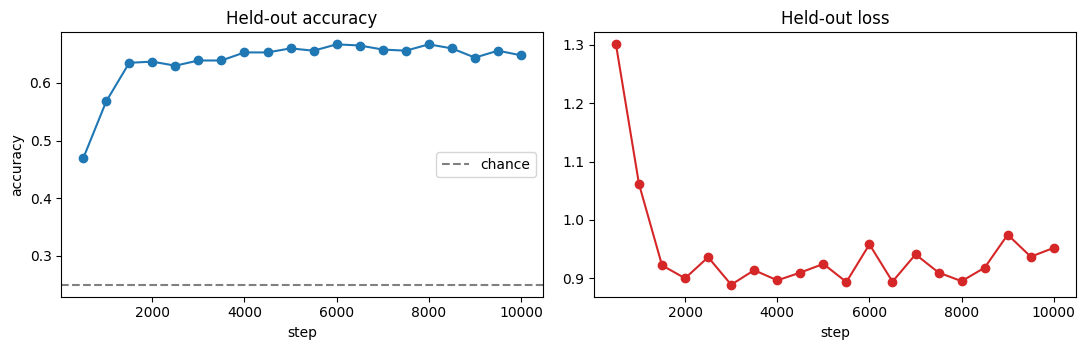

In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ev = EVAL.findall(open("/content/train.log").read())
steps = np.arange(1, len(ev) + 1) * 500
acc = np.array([float(a) for _, a, _ in ev]); loss = np.array([float(l) for l, _, _ in ev])

d = f"{LOG_DIR}/{RUN_NAME}-0"
p, y = np.load(f"{d}/test_predictions.npy"), np.load(f"{d}/test_label_ids.npy")
print(pd.DataFrame({
    "metric": ["held-out accuracy (final, step 10000)", "held-out accuracy (best checkpoint)",
               "chance level (4 classes)", "repo 'test' accuracy (TRAINING subjects, inflated)"],
    "value": [acc[-1], acc.max(), 0.25, (p.argmax(-1) == y).mean()],
}).round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(steps, acc, marker="o"); ax[0].axhline(0.25, ls="--", c="gray", label="chance")
ax[0].set(title="Held-out accuracy", xlabel="step", ylabel="accuracy"); ax[0].legend()
ax[1].plot(steps, loss, marker="o", c="tab:red"); ax[1].set(title="Held-out loss", xlabel="step")
plt.tight_layout(); plt.show()

## 10. All 9 folds (leave-one-subject-out)

The paper reports the **mean over 9 leave-one-subject-out folds** (Table 1: encoder-only with pre-training = **0.645 ± 0.104**). One fold is one test subject and is very noisy, so we run the remaining folds 1 to 8 with the identical recipe (fold 0 was run above).

Fold `i` holds out subject `A0(i+1)` (both sessions) and trains on the other 8 subjects. Two folds run concurrently on the one GPU to save time, and each finished fold is copied to Google Drive so nothing is lost if the runtime disconnects.

In [29]:
DRIVE_OUT = "/content/drive/MyDrive/neurogpt_results"
os.makedirs(DRIVE_OUT, exist_ok=True)

def fold_cmd(f):
    a = dict(args, fold_i=f)
    return "python ../src/train_gpt.py " + " ".join(f"--{k}={v}" for k, v in a.items())

def chain(folds):
    steps = [f"({fold_cmd(f)} > /content/train_fold{f}.log 2>&1; "
             f"cp -r {LOG_DIR}/{RUN_NAME}-{f} {DRIVE_OUT}/ 2>/dev/null; cp /content/train_fold{f}.log {DRIVE_OUT}/ 2>/dev/null)"
             for f in folds]
    return subprocess.Popen("cd /content/NeuroGPT/scripts && " + " ; ".join(steps), shell=True)

fold_procs = [chain([1, 3, 5, 7]), chain([2, 4, 6, 8])]
print("started 2 concurrent chains: folds 1,3,5,7 and 2,4,6,8")

started 2 concurrent chains: folds 1,3,5,7 and 2,4,6,8


### Progress

Shows each fold's current step and its latest held-out accuracy. Re-run this cell to refresh; it waits up to 20 minutes or until all folds finish.

In [34]:
import glob
STEP = re.compile(r"(\d+)/10000 \[")
def fold_status(f):
    p = f"/content/train_fold{f}.log"
    if not os.path.exists(p): return "queued"
    t = open(p, errors="ignore").read()
    ev = EVAL.findall(t)
    steps = STEP.findall(t[-3000:])
    done = os.path.exists(f"{LOG_DIR}/{RUN_NAME}-{f}/test_metrics.csv")
    last = f"{float(ev[-1][1]):.3f}" if ev else "-"
    return f"{'DONE' if done else 'running'}  step {steps[-1] if steps else '?':>5}  evals {len(ev):2d}  latest held-out acc {last}"

t0 = time.time()
while time.time() - t0 < 1200 and any(p.poll() is None for p in fold_procs):
    time.sleep(30)
for f in range(1, 9):
    print(f"fold {f} (hold out A0{f+1}):", fold_status(f))

fold 1 (hold out A02): DONE  step     ?  evals 20  latest held-out acc 0.438
fold 2 (hold out A03): DONE  step     ?  evals 20  latest held-out acc 0.743
fold 3 (hold out A04): DONE  step 10000  evals 20  latest held-out acc 0.507
fold 4 (hold out A05): DONE  step     ?  evals 20  latest held-out acc 0.562
fold 5 (hold out A06): DONE  step     ?  evals 20  latest held-out acc 0.498
fold 6 (hold out A07): DONE  step     ?  evals 20  latest held-out acc 0.696
fold 7 (hold out A08): DONE  step 10000  evals 20  latest held-out acc 0.759
fold 8 (hold out A09): DONE  step     ?  evals 20  latest held-out acc 0.615


## 11. Summary over all 9 folds vs the paper

Per-fold accuracy is the held-out accuracy **at the final step (10,000)** on the unseen subject, not the best checkpoint (choosing the best checkpoint on the test subject would leak information). Mean and standard deviation are taken across the 9 subjects. The std is the sample std (ddof = 1); the paper does not say which it uses.

 fold held_out_subject  final_acc  best_acc  n_evals
    0              A01      0.648     0.667       20
    1              A02      0.438     0.464       20
    2              A03      0.743     0.750       20
    3              A04      0.507     0.528       20
    4              A05      0.562     0.608       20
    5              A06      0.498     0.530       20
    6              A07      0.696     0.717       20
    7              A08      0.759     0.762       20
    8              A09      0.615     0.632       20

Ours   (encoder-only, pre-trained, 9-fold LOSO): 0.607 +/- 0.114
Paper  (encoder-only, pre-trained, Table 1)      : 0.645 +/- 0.104
Paper  (encoder-only, from scratch)              : 0.606 +/- 0.098


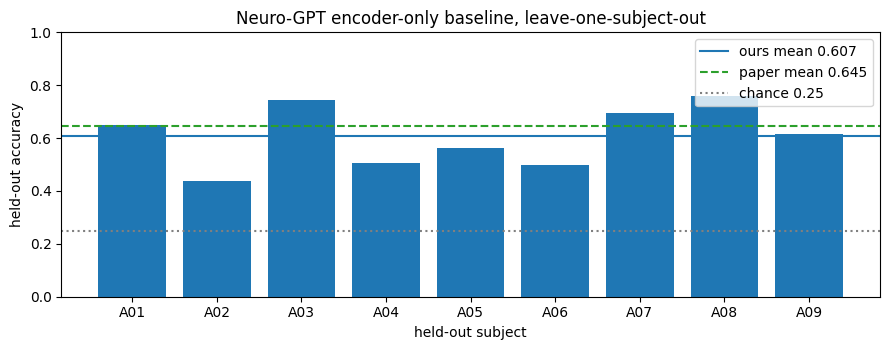

In [35]:
def fold_log(f):
    return "/content/train.log" if f == 0 else f"/content/train_fold{f}.log"

rows = []
for f in range(9):
    ev = [float(a) for _, a, _ in EVAL.findall(open(fold_log(f), errors="ignore").read())]
    rows.append({"fold": f, "held_out_subject": f"A0{f+1}", "final_acc": ev[-1], "best_acc": max(ev), "n_evals": len(ev)})
df = pd.DataFrame(rows)
print(df.round(3).to_string(index=False))

m, s = df.final_acc.mean(), df.final_acc.std(ddof=1)
print(f"\nOurs   (encoder-only, pre-trained, 9-fold LOSO): {m:.3f} +/- {s:.3f}")
print("Paper  (encoder-only, pre-trained, Table 1)      : 0.645 +/- 0.104")
print("Paper  (encoder-only, from scratch)              : 0.606 +/- 0.098")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(df.held_out_subject, df.final_acc, color="tab:blue")
ax.axhline(m, c="tab:blue", ls="-", label=f"ours mean {m:.3f}")
ax.axhline(0.645, c="tab:green", ls="--", label="paper mean 0.645")
ax.axhline(0.25, c="gray", ls=":", label="chance 0.25")
ax.set(ylim=(0, 1), ylabel="held-out accuracy", xlabel="held-out subject", title="Neuro-GPT encoder-only baseline, leave-one-subject-out")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 12. Auto-save

Copies the per-fold results, logs and the summary table to Google Drive (`MyDrive/neurogpt_results/`) so they survive a runtime reset.

In [36]:
df.to_csv(f"{DRIVE_OUT}/baseline_9fold_summary.csv", index=False)
df.to_csv(f"{LOG_DIR}/baseline_9fold_summary.csv", index=False)
for f in range(9):
    shutil.copytree(f"{LOG_DIR}/{RUN_NAME}-{f}", f"{DRIVE_OUT}/{RUN_NAME}-{f}", dirs_exist_ok=True)
    shutil.copy(fold_log(f), f"{DRIVE_OUT}/train_fold{f}.log")
!ls {DRIVE_OUT}

actual_baseline_colab-0  actual_baseline_colab-7     train_fold4.log
actual_baseline_colab-1  actual_baseline_colab-8     train_fold5.log
actual_baseline_colab-2  baseline_9fold_summary.csv  train_fold6.log
actual_baseline_colab-3  train_fold0.log	     train_fold7.log
actual_baseline_colab-4  train_fold1.log	     train_fold8.log
actual_baseline_colab-5  train_fold2.log
actual_baseline_colab-6  train_fold3.log


# Part 2: Novelty, class-conditional soft prompt-tuning

**Idea.** Keep the whole pre-trained Neuro-GPT **frozen** and learn only a small bank of continuous "prompt" tokens that is prepended to the GPT input, plus the small classifier head. This adapts the model with about 1.3M trainable parameters instead of fine-tuning the network.

- A bank of `4 classes x k tokens x 1024 dims` is prepended to **every** sequence (train and test). No true label is used to pick a prompt, so nothing about the answer leaks into the input.
- Frozen: EEG encoder, embedder, GPT-2 transformer. Trained: the prompt bank, the pooler layer and the decoding head.
- `k = 0` removes the prompts and gives a frozen-backbone probe through the same code path, a built-in ablation.

**Fair comparison.** The backbone is frozen, so the fair baselines are the paper's frozen **Linear probe (0.443)** and **Encoder+GPT (0.586)**. Our measured fine-tuned encoder-only baseline is **0.607** (section 11).

We run `k = 4` (main) and `k = 0` (ablation) on all 9 folds, with the same split, recipe and metric as the baseline.

## 13. Load the novelty code and run its smoke test

The novelty lives in separate files (`src/prompt_tuning/`, from our fork) and subclasses the vendor model, so the authors' code stays untouched. The smoke test checks prompt shapes, forward/backward in decoding mode, the `k = 0` no-op, and that freezing leaves only the prompt bank, pooler and head trainable.

In [51]:
!rm -rf /content/NeuroGPT_fork && git clone -q https://github.com/mir4gee/NeuroGPT.git /content/NeuroGPT_fork
!rm -rf /content/NeuroGPT/src/prompt_tuning /content/NeuroGPT/tests
!cp -r /content/NeuroGPT_fork/src/prompt_tuning /content/NeuroGPT/src/prompt_tuning
!cp -r /content/NeuroGPT_fork/tests /content/NeuroGPT/tests
!ls /content/NeuroGPT/src/prompt_tuning
!cd /content/NeuroGPT && python tests/test_soft_prompt.py 2>&1 | tail -8

__init__.py  soft_prompt.py  train_prompt_tuning.py
All soft-prompt smoke tests passed.


## 14. Configuration and trainable-parameter count

Same recipe as the baseline (10,000 steps, batch 32, lr 1e-4, 2 chunks of 2 s, fold split) with two changes: the encoder-only flag is dropped so the GPT path is used, and the backbone is frozen with `k` prompt tokens per class. The cell builds the model once and counts which parameters are trainable.

In [38]:
import json
nov_base = {k: v for k, v in args.items() if k not in ("ft-only-encoder", "fold_i", "run-name")}
nov_base["freeze-backbone"] = True

def nov_args(k, fold):
    a = dict(nov_base)
    a["num-prompt-tokens-per-condition"] = k
    a["fold_i"] = fold
    a["run-name"] = f"novelty_tok{k}"
    return a

def nov_cmd(k, fold):
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{a}={b}" for a, b in nov_args(k, fold).items())

probe = f'''
import sys, os, json, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "/content/NeuroGPT/src"); os.chdir("/content/NeuroGPT/scripts")
import train_gpt
from prompt_tuning import train_prompt_tuning as tpt
argv = {json.dumps([f"--{a}={b}" for a, b in nov_args(4, 0).items()])}
m = tpt.make_prompt_tuned_model(train_gpt.get_config(tpt.get_args().parse_args(argv)))
groups = {{"EEG encoder": m.encoder, "embedder": m.embedder, "GPT-2 transformer": m.decoder.transformer,
          "pooler layer": m.decoder.pooler_layer, "decoding head": m.decoder.decoding_head, "soft-prompt bank": m.soft_prompt}}
tot = tr = 0
for n, g in groups.items():
    p = sum(x.numel() for x in g.parameters()); t = sum(x.numel() for x in g.parameters() if x.requires_grad)
    tot += p; tr += t
    print(f"{{n:20s}} total {{p:>12,d}}   trainable {{t:>10,d}}")
print(f"{{'ALL':20s}} total {{tot:>12,d}}   trainable {{tr:>10,d}}  ({{100*tr/tot:.2f}}%)")
'''
open("/content/probe_params.py", "w").write(probe)
!python /content/probe_params.py 2>&1 | tail -9

Loading pretrained model from ../pretrained_model/pytorch_model.bin
EEG encoder          total      156,320   trainable          0
embedder             total    1,111,152   trainable          0
GPT-2 transformer    total   76,104,704   trainable          0
pooler layer         total    1,049,600   trainable  1,049,600
decoding head        total      270,756   trainable    270,756
soft-prompt bank     total       16,384   trainable     16,384
ALL                  total   78,708,916   trainable  1,336,740  (1.70%)


## 15. Launch: main (k = 4) and ablation (k = 0), all 9 folds

Two chains run concurrently on the one GPU (one per setting, folds 0 to 8 in order). Each finished fold is copied to Google Drive. Accuracy is the held-out evaluation at the final step on the unseen subject, exactly as for the baseline.

In [39]:
def nov_chain(k, folds):
    steps = [f"({nov_cmd(k, f)} > /content/nov_tok{k}_fold{f}.log 2>&1; "
             f"cp -r {LOG_DIR}/novelty_tok{k}-{f} {DRIVE_OUT}/ 2>/dev/null; cp /content/nov_tok{k}_fold{f}.log {DRIVE_OUT}/ 2>/dev/null)"
             for f in folds]
    return subprocess.Popen("cd /content/NeuroGPT/scripts && " + " ; ".join(steps), shell=True)

nov_procs = [nov_chain(4, range(9)), nov_chain(0, range(9))]
print("started: novelty k=4 (folds 0-8) and ablation k=0 (folds 0-8)")

started: novelty k=4 (folds 0-8) and ablation k=0 (folds 0-8)


### Progress

Shows each run's step count and latest held-out accuracy, and prints the log tail if a run crashed. Re-run to refresh; it waits up to `WAIT_S` seconds or until all runs finish.

In [41]:
WAIT_S = 240

def nov_status(k, f):
    p = f"/content/nov_tok{k}_fold{f}.log"
    if not os.path.exists(p): return "queued"
    t = open(p, errors="ignore").read()
    ev = EVAL.findall(t)
    steps = STEP.findall(t[-3000:])
    done = os.path.exists(f"{LOG_DIR}/novelty_tok{k}-{f}/test_metrics.csv")
    if "Traceback" in t and not done: return "CRASHED\n" + t[-1500:]
    last = f"{float(ev[-1][1]):.3f}" if ev else "-"
    return f"{'DONE' if done else 'running'}  step {steps[-1] if steps else '?':>5}  evals {len(ev):2d}  latest held-out acc {last}"

t0 = time.time()
while time.time() - t0 < WAIT_S and any(p.poll() is None for p in nov_procs):
    time.sleep(20)
for k in (4, 0):
    print(f"--- k = {k} tokens per class ---")
    for f in range(9):
        s_ = nov_status(k, f)
        if s_ != "queued": print(f"fold {f} (A0{f+1}):", s_)

--- k = 4 tokens per class ---
fold 0 (A01): running  step  2016  evals  4  latest held-out acc 0.255
--- k = 0 tokens per class ---
fold 0 (A01): running  step  2457  evals  4  latest held-out acc 0.255


## 16. The first attempt (as specified) does not learn: diagnosis

Result of the runs above (`k = 4` and `k = 0`, original readout, fold 0): the training loss stayed at **1.39 = ln 4**, which is pure chance, and held-out accuracy stayed at about **0.25** for all 4 evaluations (2,000 steps). Both runs were stopped early instead of burning 3 hours.

The cell below finds where the information is lost. It extracts features at two points of the frozen model and fits a logistic-regression linear probe on each (fold 0: train on 8 subjects, test on the unseen subject A01).

In [44]:
diag = f'''
import sys, os, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, torch
from torch.utils.data import DataLoader
sys.path.insert(0, "/content/NeuroGPT/src"); os.chdir("/content/NeuroGPT/scripts")
import train_gpt
from prompt_tuning import train_prompt_tuning as tpt
argv = {json.dumps([f"--{a}={b}" for a, b in nov_args(0, 0).items()])}
cfg = train_gpt.get_config(tpt.get_args().parse_args(argv))
model = tpt.make_prompt_tuned_model(cfg).cuda().eval()
files = sorted(os.listdir(cfg["dst_data_path"]))[:18]
trf, tef = train_gpt.cv_split_bci(files)
kw = dict(sample_keys=["inputs", "attention_mask"], chunk_len=cfg["chunk_len"], num_chunks=cfg["num_chunks"],
          ovlp=cfg["chunk_ovlp"], root_path=cfg["dst_data_path"], gpt_only=not cfg["use_encoder"])
cap = {{}}
model.encoder.register_forward_hook(lambda m, i, o: cap.__setitem__("enc", o.detach().float().cpu()))
model.decoder.pooler_layer.register_forward_hook(lambda m, i, o: cap.__setitem__("pool_in", i[0].detach().float().cpu()))
def feats(ds):
    E, P, Y = [], [], []
    for b in DataLoader(ds, batch_size=64, num_workers=0):
        b = {{k: v.cuda() for k, v in b.items()}}
        with torch.no_grad(): model(b)
        B = b["inputs"].shape[0]
        E.append(cap["enc"].reshape(B, -1).numpy()); P.append(cap["pool_in"].numpy()); Y.append(b["labels"].cpu().numpy())
    return np.concatenate(E), np.concatenate(P), np.concatenate(Y)
Etr, Ptr, Ytr = feats(train_gpt.MotorImageryDataset(trf[0], **kw))
Ete, Pte, Yte = feats(train_gpt.MotorImageryDataset(tef[0], **kw))
print("shapes: enc", Etr.shape, " gpt-last-token", Ptr.shape, " labels", np.bincount(Ytr))
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
for name, A, B in (("encoder output (frozen)", Etr, Ete), ("GPT last token -> pooler input", Ptr, Pte)):
    sc = StandardScaler().fit(A)
    clf = LogisticRegression(max_iter=300, C=0.1).fit(sc.transform(A), Ytr)
    print(f"{{name:34s}} per-feature std mean {{A.std(0).mean():9.4f}} | max |mean| {{np.abs(A.mean(0)).max():9.3f}} | train acc {{clf.score(sc.transform(A), Ytr):.3f}} | held-out acc {{clf.score(sc.transform(B), Yte):.3f}}")
cs = lambda X: float(np.mean((X[:200] @ X[:200].T / (np.linalg.norm(X[:200], axis=1)[:, None] * np.linalg.norm(X[:200], axis=1)[None])).ravel()))
print("mean pairwise cosine between samples: enc", round(cs(Etr), 3), "| gpt-last-token", round(cs(Ptr), 3))
'''
open("/content/diag.py", "w").write(diag)
!python /content/diag.py 2>&1 | tail -12

Loading pretrained model from ../pretrained_model/pytorch_model.bin
Number of subjects loaded:  16
Number of subjects loaded:  2
shapes: enc (4608, 2160)  gpt-last-token (4608, 1024)  labels [1152 1152 1152 1152]
encoder output (frozen)            per-feature std mean    0.2968 | max |mean|     2.104 | train acc 0.769 | held-out acc 0.493
GPT last token -> pooler input     per-feature std mean    0.1179 | max |mean|     6.721 | train acc 0.498 | held-out acc 0.356
mean pairwise cosine between samples: enc 0.887 | gpt-last-token 0.972


**Reading the diagnostic (fold 0)**

| Features | Linear-probe held-out accuracy | Mean cosine between samples |
|---|---|---|
| Frozen EEG-encoder output | **0.493** (train 0.769) | 0.887 |
| Frozen GPT last-token state (what the original head reads) | **0.356** (train 0.498) | 0.972 |

- The class information **is** in the frozen encoder features (0.49, consistent with the paper's frozen Linear probe, 0.443).
- The frozen GPT's last-token state is almost the **same vector for every sample** (cosine 0.97; a few dimensions have a large constant offset, up to 6.7, against a per-feature spread of about 0.12). Even the best linear classifier on it reaches only 0.36, so the original head has almost nothing to learn from. This is the main reason the first attempt stayed at chance.
- A plausible cause (not tested here): the GPT was pre-trained to *predict the next chunk's embedding*, so its output at the last position is a generic prediction, not a summary of the current chunk.

**Fix.** Keep everything frozen and keep the prompts, but add a trainable linear skip from the frozen encoder features into the readout (`--readout=skip`). The prompts still steer the frozen GPT; the head can now also use the information the encoder preserves. The default `--readout=gpt` is the original spec and is unchanged. In the `k = 0` ablation this reduces to a frozen encoder plus a small learned head, so `k = 4` versus `k = 0` isolates what the prompts add.

## 17. Launch the fixed version (`readout=skip`): k = 4 and k = 0, all 9 folds

Same split, recipe and metric as the baseline. Two chains run concurrently on the one GPU; each finished fold is copied to Drive.

In [46]:
def v2_args(k, fold):
    a = nov_args(k, fold)
    a["readout"] = "skip"
    a["run-name"] = f"novelty_skip_tok{k}"
    return a

def v2_cmd(k, fold):
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{a}={b}" for a, b in v2_args(k, fold).items())

def v2_chain(k, folds):
    steps = [f"({v2_cmd(k, f)} > /content/v2_tok{k}_fold{f}.log 2>&1; "
             f"cp -r {LOG_DIR}/novelty_skip_tok{k}-{f} {DRIVE_OUT}/ 2>/dev/null; cp /content/v2_tok{k}_fold{f}.log {DRIVE_OUT}/ 2>/dev/null)"
             for f in folds]
    return subprocess.Popen("cd /content/NeuroGPT/scripts && " + " ; ".join(steps), shell=True)

v2_procs = [v2_chain(4, range(9)), v2_chain(0, range(9))]
print("started readout=skip: k=4 (folds 0-8) and k=0 (folds 0-8)")

started readout=skip: k=4 (folds 0-8) and k=0 (folds 0-8)


### Progress (fixed version)

Re-run to refresh; it waits up to `WAIT_S` seconds or until all runs finish, and prints the log tail of any crashed run.

In [48]:
WAIT_S2 = 420

def v2_status(k, f):
    p = f"/content/v2_tok{k}_fold{f}.log"
    if not os.path.exists(p): return "queued"
    t = open(p, errors="ignore").read()
    ev = EVAL.findall(t)
    steps = STEP.findall(t[-3000:])
    done = os.path.exists(f"{LOG_DIR}/novelty_skip_tok{k}-{f}/test_metrics.csv")
    if "Traceback" in t and not done: return "CRASHED\n" + t[-1500:]
    last = f"{float(ev[-1][1]):.3f}" if ev else "-"
    hist = " ".join(f"{float(a):.2f}" for _, a, _ in ev[-6:])
    return f"{'DONE' if done else 'running'}  step {steps[-1] if steps else '?':>5}  evals {len(ev):2d}  last held-out accs: {hist}"

t0 = time.time()
while time.time() - t0 < WAIT_S2 and any(p.poll() is None for p in v2_procs):
    time.sleep(20)
for k in (4, 0):
    print(f"--- readout=skip, k = {k} tokens per class ---")
    for f in range(9):
        s_ = v2_status(k, f)
        if s_ != "queued": print(f"fold {f} (A0{f+1}):", s_)

--- readout=skip, k = 4 tokens per class ---
fold 0 (A01): running  step  4320  evals  8  last held-out accs: 0.26 0.33 0.28 0.29 0.31 0.29
--- readout=skip, k = 0 tokens per class ---
fold 0 (A01): running  step  5327  evals 10  last held-out accs: 0.29 0.32 0.27 0.27 0.29 0.25


In [50]:
for p in v2_procs:
    p.kill()
!pkill -f train_prompt_tuning; sleep 3; pgrep -fa train_prompt_tuning | wc -l

def probe_cmd(lr):
    a = v2_args(0, 0)
    a.update({"learning-rate": lr, "run-name": f"lrprobe_{lr}", "training-steps": 2000,
              "eval_every_n_steps": 2000, "log-every-n-steps": 100})
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{k}={v}" for k, v in a.items())

LRS = [3e-4, 1e-3, 3e-3]
probe_procs = [subprocess.Popen(f"cd /content/NeuroGPT/scripts && {probe_cmd(lr)} > /content/lrprobe_{lr}.log 2>&1", shell=True) for lr in LRS]
t0 = time.time()
while time.time() - t0 < 900 and any(p.poll() is None for p in probe_procs):
    time.sleep(20)
for lr in LRS:
    t = open(f"/content/lrprobe_{lr}.log", errors="ignore").read()
    losses = [float(x) for x in re.findall(r"\{'loss': ([\d.]+)", t)]
    print(f"lr {lr:g}: train loss every 100 steps -> {' '.join(f'{x:.2f}' for x in losses)}" + ("  [CRASH]" if "Traceback" in t else ""))

^C
lr 0.0003: train loss every 100 steps -> 1.43 1.42 1.39 1.38 1.36 1.34 1.35 1.34 1.33 1.33 1.33 1.33 1.32 1.31 1.31 1.31 1.31 1.31 1.29 1.30 1.29
lr 0.001: train loss every 100 steps -> 1.43 1.44 1.42 1.41 1.40 1.39 1.39 1.38 1.37 1.37 1.37 1.36 1.36 1.35 1.36 1.35 1.35 1.35 1.34 1.35 1.34
lr 0.003: train loss every 100 steps -> 1.43 1.45 1.41 1.41 1.40 1.39 1.40 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39 1.39


### Iteration 2: standardise the readout input, then re-check the learning rate

None of the learning rates fits the training data (above): training loss stays near chance, and the largest one is stuck at exactly ln 4, a sign of the saturated `tanh` pooler fed by the large constant offset in the GPT features. The diagnostic probe worked only after standardising the features, so the model now does the same: a parameter-free `BatchNorm1d` on the pooler input (`readout=skip`). The selection rule is unchanged and uses **training loss only**: take the smallest learning rate whose training loss falls clearly below chance (under 1.0) within 2,000 steps.

In [52]:
LRS2 = [1e-4, 3e-4, 1e-3, 3e-3]

def probe2_cmd(lr):
    a = v2_args(0, 0)
    a.update({"learning-rate": lr, "run-name": f"lrprobe2_{lr}", "training-steps": 2000,
              "eval_every_n_steps": 2000, "log-every-n-steps": 100})
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{k}={v}" for k, v in a.items())

probe2_procs = [subprocess.Popen(f"cd /content/NeuroGPT/scripts && {probe2_cmd(lr)} > /content/lrprobe2_{lr}.log 2>&1", shell=True) for lr in LRS2]
t0 = time.time()
while time.time() - t0 < 1000 and any(p.poll() is None for p in probe2_procs):
    time.sleep(20)
for lr in LRS2:
    t = open(f"/content/lrprobe2_{lr}.log", errors="ignore").read()
    losses = [float(x) for x in re.findall(r"\{'loss': ([\d.]+)", t)]
    print(f"lr {lr:g}: train loss every 100 steps -> {' '.join(f'{x:.2f}' for x in losses)}" + ("  [CRASH]" if "Traceback" in t else ""))

lr 0.0001: train loss every 100 steps -> 
lr 0.0003: train loss every 100 steps -> 1.43 1.39 1.36 1.36 1.36 1.33 1.33 1.34 1.32 1.32 1.32 1.32 1.31 1.31 1.31 1.30 1.31 1.31 1.29 1.30 1.29
lr 0.001: train loss every 100 steps -> 1.43 1.43 1.40 1.39 1.37 1.35 1.34 1.34 1.33 1.32 1.33 1.31 1.32 1.31 1.31 1.30 1.30 1.30 1.29 1.29 1.28
lr 0.003: train loss every 100 steps -> 


### Iteration 3: the frozen backbone must stay in eval mode

The loss curves above barely move with either the learning rate or the normalisation, which points at the features themselves. The frozen EEG encoder contains **dropout (p = 0.5) and BatchNorm**, and "frozen" only stops gradient updates: in training mode both stay active, so the head sees heavily corrupted features during training but clean ones at test time. The diagnostic probe used eval mode, which is why it worked. The fix is in the model: a frozen backbone is now kept in eval mode while the prompts, pooler and head train (`PromptTunedModel.train()` override, unit-tested).

Same selection rule as before, on training loss only. Both readouts (`gpt` = original spec, `skip` = with encoder skip) at `k = 4`, learning rates 3e-4 and 1e-3, 2,000 steps on fold 0.

In [53]:
for p in probe2_procs:
    p.kill()
!pkill -f train_prompt_tuning; sleep 2
!rm -rf /content/NeuroGPT_fork && git clone -q https://github.com/mir4gee/NeuroGPT.git /content/NeuroGPT_fork
!rm -rf /content/NeuroGPT/src/prompt_tuning /content/NeuroGPT/tests && cp -r /content/NeuroGPT_fork/src/prompt_tuning /content/NeuroGPT/src/ && cp -r /content/NeuroGPT_fork/tests /content/NeuroGPT/tests
!cd /content/NeuroGPT && python tests/test_soft_prompt.py 2>&1 | tail -1

def p3_cmd(readout, lr, k=4, fold=0, steps=2000):
    a = v2_args(k, fold)
    a.update({"readout": readout, "learning-rate": lr, "run-name": f"p3_{readout}_{lr}", "training-steps": steps,
              "eval_every_n_steps": steps, "log-every-n-steps": 100})
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{a_}={b}" for a_, b in a.items())

CASES = [("gpt", 3e-4), ("gpt", 1e-3), ("skip", 3e-4), ("skip", 1e-3)]
p3_procs = [subprocess.Popen(f"cd /content/NeuroGPT/scripts && {p3_cmd(r, lr)} > /content/p3_{r}_{lr}.log 2>&1", shell=True) for r, lr in CASES]
t0 = time.time()
while time.time() - t0 < 1000 and any(p.poll() is None for p in p3_procs):
    time.sleep(20)
for r, lr in CASES:
    t = open(f"/content/p3_{r}_{lr}.log", errors="ignore").read()
    losses = [float(x) for x in re.findall(r"\{'loss': ([\d.]+)", t)]
    print(f"{r:5s} lr {lr:g}: train loss every 100 steps -> {' '.join(f'{x:.2f}' for x in losses)}" + ("  [CRASH]" if "Traceback" in t else ""))

^C
All soft-prompt smoke tests passed.
gpt   lr 0.0003: train loss every 100 steps -> 
gpt   lr 0.001: train loss every 100 steps -> 
skip  lr 0.0003: train loss every 100 steps -> 1.41 1.37 1.33 1.30 1.29 1.26 1.25 1.21 1.23 1.19 1.19 1.17 1.14 1.13 1.11 1.10 1.08 1.05 1.03 1.04 1.02
skip  lr 0.001: train loss every 100 steps -> 


In [55]:
CASES_RERUN = [("gpt", 3e-4), ("gpt", 1e-3), ("skip", 1e-3)]   # 4 concurrent runs exceeded the 12 GB host RAM (OOM-killed); 3 fit
p3b = [subprocess.Popen(f"cd /content/NeuroGPT/scripts && {p3_cmd(r, lr)} > /content/p3_{r}_{lr}.log 2>&1", shell=True) for r, lr in CASES_RERUN]
t0 = time.time()
while time.time() - t0 < 1000 and any(p.poll() is None for p in p3b):
    time.sleep(20)
for r, lr in CASES:
    t = open(f"/content/p3_{r}_{lr}.log", errors="ignore").read()
    losses = [float(x) for x in re.findall(r"\{'loss': ([\d.]+)", t)]
    print(f"{r:5s} lr {lr:g}: train loss every 100 steps -> {' '.join(f'{x:.2f}' for x in losses)}" + ("  [KILLED/CRASH]" if ("Traceback" in t or t.rstrip().endswith("Killed")) else ""))

gpt   lr 0.0003: train loss every 100 steps -> 1.38 1.42 1.41 1.41 1.40 1.40 1.39 1.39 1.39 1.38 1.38 1.38 1.38 1.37 1.36 1.37 1.37 1.36 1.37 1.36 1.36
gpt   lr 0.001: train loss every 100 steps -> 1.38 1.44 1.43 1.41 1.40 1.40 1.39 1.39 1.38 1.38 1.38 1.38 1.38 1.38 1.36 1.37 1.37 1.36 1.37 1.35 1.36
skip  lr 0.0003: train loss every 100 steps -> 1.41 1.37 1.33 1.30 1.29 1.26 1.25 1.21 1.23 1.19 1.19 1.17 1.14 1.13 1.11 1.10 1.08 1.05 1.03 1.04 1.02
skip  lr 0.001: train loss every 100 steps -> 1.41 1.41 1.38 1.34 1.31 1.28 1.28 1.25 1.24 1.21 1.21 1.18 1.16 1.15 1.11 1.12 1.09 1.06 1.02 1.04 1.01


### Result of the learning-rate / readout check (fold 0, training loss only, 2,000 steps)

| Readout | lr 3e-4 | lr 1e-3 |
|---|---|---|
| `gpt` (original spec) | 1.36 | 1.36 |
| `skip` (encoder skip + standardisation) | 1.02 | 1.01 |

- With the frozen backbone now correctly in eval mode, the **original readout still barely learns** (loss 1.36, chance is 1.39), which confirms the diagnostic: the frozen GPT discards most class information.
- The `skip` readout **fits the training data** (loss about 1.0 and still falling).
- Neither `skip` setting strictly reaches the pre-declared "under 1.0" at 2,000 steps, and 1.02 vs 1.01 are indistinguishable, so the tie-break is the smaller learning rate: **3e-4** for all novelty runs. The baseline keeps the paper's 1e-4.
- Practical note: more than 3 runs at once exceed the 12 GB of host RAM, so at most 2 run concurrently below.

## 18. Final runs (all 9 folds, lr 3e-4)

- `skip`, k = 4 (main) and `skip`, k = 0 (ablation: frozen encoder + head, no prompts).
- `gpt`, k = 4: the original-spec readout, kept as a documented negative result.

Two chains run concurrently, balanced over the three settings; every finished fold is copied to Drive.

In [56]:
FINAL_LR = 3e-4
SETTINGS = {"skip_k4": ("skip", 4), "skip_k0": ("skip", 0), "gpt_k4": ("gpt", 4)}

def final_cmd(tag, fold):
    readout, k = SETTINGS[tag]
    a = nov_args(k, fold)
    a.update({"readout": readout, "learning-rate": FINAL_LR, "run-name": f"nov_{tag}"})
    return "python ../src/prompt_tuning/train_prompt_tuning.py " + " ".join(f"--{a_}={b}" for a_, b in a.items())

def final_chain(jobs):
    steps = [f"({final_cmd(t, f)} > /content/final_{t}_fold{f}.log 2>&1; "
             f"cp -r {LOG_DIR}/nov_{t}-{f} {DRIVE_OUT}/ 2>/dev/null; cp /content/final_{t}_fold{f}.log {DRIVE_OUT}/ 2>/dev/null)"
             for t, f in jobs]
    return subprocess.Popen("cd /content/NeuroGPT/scripts && " + " ; ".join(steps), shell=True)

chain_a = [("skip_k4", f) for f in range(9)] + [("gpt_k4", f) for f in range(5)]
chain_b = [("skip_k0", f) for f in range(9)] + [("gpt_k4", f) for f in range(5, 9)]
final_procs = [final_chain(chain_a), final_chain(chain_b)]
print(f"started: chain A {len(chain_a)} runs, chain B {len(chain_b)} runs")

started: chain A 14 runs, chain B 13 runs


### Progress (final runs)

Re-run to refresh; it waits up to `WAIT_S3` seconds or until all runs finish. Crashes print the log tail.

In [1]:
WAIT_S3 = 1500

def final_acc(tag, f):
    p = f"/content/final_{tag}_fold{f}.log"
    if not os.path.exists(p): return None, "queued", None
    t = open(p, errors="ignore").read()
    ev = [float(a) for _, a, _ in EVAL.findall(t)]
    done = os.path.exists(f"{LOG_DIR}/nov_{tag}-{f}/test_metrics.csv")
    if ("Traceback" in t or t.rstrip().endswith("Killed")) and not done: return None, "CRASHED", t[-800:]
    st = STEP.findall(t[-3000:])
    return (ev[-1] if (done and ev) else None), ("done" if done else f"running step {st[-1] if st else '?'}"), None

t0 = time.time()
while time.time() - t0 < WAIT_S3 and any(p.poll() is None for p in final_procs):
    time.sleep(20)
for tag in SETTINGS:
    done_s, run_s = [], ""
    for f in range(9):
        a, st, err = final_acc(tag, f)
        if st == "CRASHED": run_s += f" f{f}:CRASHED\n{err}"
        elif a is not None: done_s.append(f"f{f} {a:.3f}")
        elif st != "queued": run_s += f" | f{f} {st}"
    print(f"{tag:8s} {' '.join(done_s)}{run_s}")

NameError: name 'time' is not defined

## 19. Results: novelty vs baseline (9-fold leave-one-subject-out)

Held-out accuracy at the final step on the unseen subject, same split and metric as the baseline. Settings:

- **baseline**: authors' recipe, fine-tuned encoder (section 11), lr 1e-4.
- **skip_k4**: frozen backbone + 4 prompt tokens per class + encoder skip (main novelty, lr 3e-4).
- **skip_k0**: the same without prompt tokens (ablation: frozen encoder + head).
- **gpt_k4**: original-spec readout (frozen GPT last token only), kept as a negative result.

`skip_k4` vs `skip_k0` isolates what the prompt tokens add. The paired tests use only 9 subjects, so treat them as indicative.

In [ ]:
from scipy.stats import ttest_rel, wilcoxon

res = pd.DataFrame({"baseline": df.final_acc.values}, index=[f"A0{f+1}" for f in range(9)])
for tag in SETTINGS:
    res[tag] = [final_acc(tag, f)[0] if final_acc(tag, f)[0] is not None else np.nan for f in range(9)]
print(res.round(3).to_string())
summary = pd.DataFrame({"mean": res.mean(), "std": res.std(ddof=1), "n_folds": res.count()}).round(3)
print("\n", summary.to_string())
print("\nPaper (Table 1): linear probe 0.443 +/- 0.051 | encoder-only 0.645 +/- 0.104 | encoder+GPT 0.586 +/- 0.098 | chance 0.250")

def paired(a, b):
    m = res[[a, b]].dropna()
    if len(m) < 3: return f"{a} vs {b}: not enough finished folds"
    d = m[a] - m[b]
    return (f"{a} - {b}: mean diff {d.mean():+.3f} (n={len(m)}), paired t p={ttest_rel(m[a], m[b]).pvalue:.3f}, "
            f"Wilcoxon p={wilcoxon(m[a], m[b]).pvalue:.3f}, folds where first is higher: {(d > 0).sum()}/{len(m)}")
print()
for a, b in (("skip_k4", "skip_k0"), ("skip_k4", "baseline"), ("skip_k4", "gpt_k4")):
    print(paired(a, b))

ax = res.plot(kind="bar", figsize=(11, 4), width=0.8)
ax.axhline(0.25, c="gray", ls=":", label="chance"); ax.set(ylim=(0, 1), ylabel="held-out accuracy", xlabel="held-out subject",
        title="Prompt-tuned frozen Neuro-GPT vs fine-tuned baseline")
ax.legend(ncol=5, fontsize=8, loc="upper center"); plt.tight_layout(); plt.show()

## 20. Auto-save (novelty)

Writes the result table to Drive and to the results folder.

In [ ]:
res.round(4).to_csv(f"{DRIVE_OUT}/novelty_vs_baseline_9fold.csv")
res.round(4).to_csv(f"{LOG_DIR}/novelty_vs_baseline_9fold.csv")
summary.to_csv(f"{DRIVE_OUT}/novelty_summary.csv")
!ls {DRIVE_OUT} | grep -c nov_ ; ls {DRIVE_OUT}/*.csv

In [ ]:
print(time.strftime("%H:%M:%S"), [p.poll() for p in final_procs])
for tag in SETTINGS:
    row = []
    for f in range(9):
        a, st, err = final_acc(tag, f)
        row.append(f"f{f} {a:.3f}" if a is not None else (f"f{f} {st}" if st != "queued" else ""))
    print(f"{tag:8s}", " ".join(x for x in row if x))

In [3]:
import os, time, subprocess, glob
print("now", time.strftime("%H:%M:%S"), "| uptime:", subprocess.run("uptime -p", shell=True, capture_output=True, text=True).stdout.strip())
print("procs:", subprocess.run("pgrep -fa train_prompt_tuning | wc -l", shell=True, capture_output=True, text=True).stdout.strip())
print("drive mounted:", os.path.ismount("/content/drive"), "| /content/results:", os.path.isdir("/content/results"), "| npz:", len(glob.glob("/content/bci2a_egg_npz/*.npz")))
for p in sorted(glob.glob("/content/final_*_fold*.log")):
    t = open(p, errors="ignore").read()
    print(os.path.basename(p), len(t), "done" if os.path.exists(p.replace("/content/final_", "/content/results/nov_").replace("_fold", "-").replace(".log", "") + "/test_metrics.csv") else "-")
d = "/content/drive/MyDrive/neurogpt_results"
print("drive results:", sorted(os.listdir(d))[:60] if os.path.isdir(d) else "no drive dir")

now 07:30:31 | uptime: up 24 minutes
procs: 1
drive mounted: False | /content/results: False | npz: 0
drive results: no drive dir
